# named op or generic op
BMM, bsx197x1024, bsx1024x197 => MM, bs*197x1024, 1024xbs*197

In [1]:
import numpy as np
import torch
import torch.utils.benchmark as benchmark
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
#import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import wraps
from time import perf_counter
from collections import namedtuple

from ragdoll.utils import *
from ragdoll.visualisation import *
from ragdoll.benchmark import *
import ragdoll

/tmp/ipykernel_1809283/3465895806.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [15]:
model_file = "mm_src.mlir"
target_file = "mm_src.mlir.demo"
target_file2 = "mm_src.demo.mlir"
!ragdoll-opt {model_file}  \
--canonicalize \
--enable-cse-in-legalizer \
--symbol-dce \
--ragdoll-autodiff-vjp-public-functions='strategy=heuristic' \
--ragdoll-autodiff-vjp \
--ragdoll-raise-linalg-to-tosa \
 > {target_file}
#!ragdoll-opt {target_file}  -pass-pipeline="builtin.module(func.func(tosa-to-linalg-named,linalg-generalize-named-ops,canonicalize,linalg-fuse-elementwise-ops))" > {target_file2}
!ragdoll-opt {target_file}  -pass-pipeline="builtin.module(func.func(canonicalize,linalg-fuse-elementwise-ops))" > {target_file2}
!cat {target_file2}

#map = affine_map<(d0, d1, d2, d3) -> (d0, d3, d2)>
#map1 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d2)>
#map2 = affine_map<(d0, d1, d2, d3) -> (d0, d1, d3)>
module {
  ml_program.global private mutable @global1 : tensor<2x31x30xf32>
  ml_program.global private mutable @global0 : tensor<2x32x31xf32>
  func.func @matmul(%arg0: tensor<2x32x31xf32>, %arg1: tensor<2x31x30xf32>) -> tensor<2x32x30xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    ml_program.global_store @global1 = %arg1 : tensor<2x31x30xf32>
    ml_program.global_store @global0 = %arg0 : tensor<2x32x31xf32>
    %0 = tensor.empty() : tensor<2x32x30xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<2x32x30xf32>) -> tensor<2x32x30xf32>
    %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<2x32x31xf32>, tensor<2x31x30xf32>) outs(%1 : tensor<2x32x30xf32>) -> tensor<2x32x30xf32>
    return %2 : tensor<2x32x30xf32>
  }
  func.func @dmatmul(%arg0: tensor<2x32x30xf32>) -> (tensor<2x32x31xf32>, tensor<2x31x30xf32>) {
 

In [2]:

gen_results = []
gen_throughput = []
for size in list(range(16, 1000, 16)):
    B = 2
    M = size
    N = size
    K = size
    print("benchmarking {}x{}x{}".format(size, size, size))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{B}x{M}x{K}xf32>, %arg1: tensor<{B}x{K}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{B}x{M}x{N}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{B}x{M}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32>
        %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<{B}x{M}x{K}xf32>, tensor<{B}x{K}x{N}xf32>) outs(%1 : tensor<{B}x{M}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32>
        return %2 : tensor<{B}x{M}x{N}xf32>
      BRKRIGHT
    BRKRIGHT"""

    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    #"""
    !ragdoll-opt {mlir_file_name} --linalg-generalize-named-ops > {mlir_file_name}.generic
    !iree-compile {mlir_file_name}.generic \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_86
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb",
        [(B, M, K), (B, K, N)],
        device='gpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    gen_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*M*K*N*1000000000
    gen_throughput.append(GFLOPS/np.mean(ragdoll_bench))
gen_data = pd.DataFrame([list(range(16, 1000, 16)), gen_results])
gen_data.to_csv('op_spec_generic_gpu.csv')

benchmarking 16x16x16


/root/AlbertResearches/researches/Ragdoll/ragdoll/benchmark/op_benchmark.py:192: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


benchmarking 32x32x32


KeyboardInterrupt: 

In [3]:

mm_results = []
mm_throughput = []
for size in list(range(16, 1000, 16)):
    B = 2
    M = size
    N = size
    K = size
    print("benchmarking {}x{}x{}".format(size, size, size))
    BENCH_CNT=33
    mm_src = f"""module BRKLEFT
      func.func @matmul(%arg0: tensor<{B}x{M}x{K}xf32>, %arg1: tensor<{B}x{K}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32> BRKLEFT
        %cst = arith.constant 0.000000e+00 : f32
        %0 = tensor.empty() : tensor<{B}x{M}x{N}xf32>
        %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<{B}x{M}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32>
        %2 = linalg.batch_matmul ins(%arg0, %arg1 : tensor<{B}x{M}x{K}xf32>, tensor<{B}x{K}x{N}xf32>) outs(%1 : tensor<{B}x{M}x{N}xf32>) -> tensor<{B}x{M}x{N}xf32>
        return %2 : tensor<{B}x{M}x{N}xf32>
      BRKRIGHT
    BRKRIGHT"""

    mm_src = mm_src.replace("BRKLEFT", "{")
    mm_src = mm_src.replace("BRKRIGHT", "}")
    
    mlir_file_name = "mm_src.mlir"
    with open(mlir_file_name, "w", encoding="utf-8") as mlir_file:
        mlir_file.write(mm_src)
    #"""
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-hal-cuda-llvm-target-arch=sm_86
    """
    !iree-compile {mlir_file_name} \
    -o {mlir_file_name}.vmfb \
    --iree-hal-target-backends=llvm-cpu \
    --iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0 \
    --iree-opt-const-eval=1 \
    --iree-opt-const-expr-hoisting=1 \
    --iree-opt-numeric-precision-reduction=1 \
    --iree-llvmcpu-target-cpu-features=host \
    --iree-llvmcpu-enable-ukernels=all \
    --iree-llvmcpu-slp-vectorization=1 \
    --iree-hal-benchmark-dispatch-repeat-count={BENCH_CNT} \
    --iree-llvmcpu-target-triple=x86_64-pc-linux-elf
    """
    #print(tf_bench)
    
    
    ragdoll_bench = ragdoll_op_benchmark(
        mlir_file_name + ".vmfb",
        [(B, M, K), (B, K, N)],
        device='gpu',
        warmups=3,
        repetitions=BENCH_CNT, 
        measure_count=1)
    #print(np.mean(ragdoll_bench))
    mm_results.append(np.mean(ragdoll_bench))
    GFLOPS = 2*M*K*N*1000000000
    mm_throughput.append(GFLOPS/np.mean(ragdoll_bench))
mm_data = pd.DataFrame([list(range(16, 1000, 16)), mm_results])
mm_data.to_csv('op_spec_named_gpu.csv')

benchmarking 16x16x16
benchmarking 32x32x32
benchmarking 48x48x48
benchmarking 64x64x64
benchmarking 80x80x80
benchmarking 96x96x96
benchmarking 112x112x112
benchmarking 128x128x128
benchmarking 144x144x144
benchmarking 160x160x160
benchmarking 176x176x176
benchmarking 192x192x192
benchmarking 208x208x208
benchmarking 224x224x224
benchmarking 240x240x240
benchmarking 256x256x256
benchmarking 272x272x272
benchmarking 288x288x288
benchmarking 304x304x304
benchmarking 320x320x320
benchmarking 336x336x336
benchmarking 352x352x352
benchmarking 368x368x368
benchmarking 384x384x384
benchmarking 400x400x400
benchmarking 416x416x416
benchmarking 432x432x432
benchmarking 448x448x448
benchmarking 464x464x464
benchmarking 480x480x480
benchmarking 496x496x496
benchmarking 512x512x512
benchmarking 528x528x528
benchmarking 544x544x544
benchmarking 560x560x560
benchmarking 576x576x576
benchmarking 592x592x592
benchmarking 608x608x608
benchmarking 624x624x624
benchmarking 640x640x640
benchmarking 656x6

/tmp/ipykernel_1288232/3063586469.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)
/tmp/ipykernel_1288232/3063586469.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  right.set_xticklabels(right.get_xticklabels(), rotation=30)


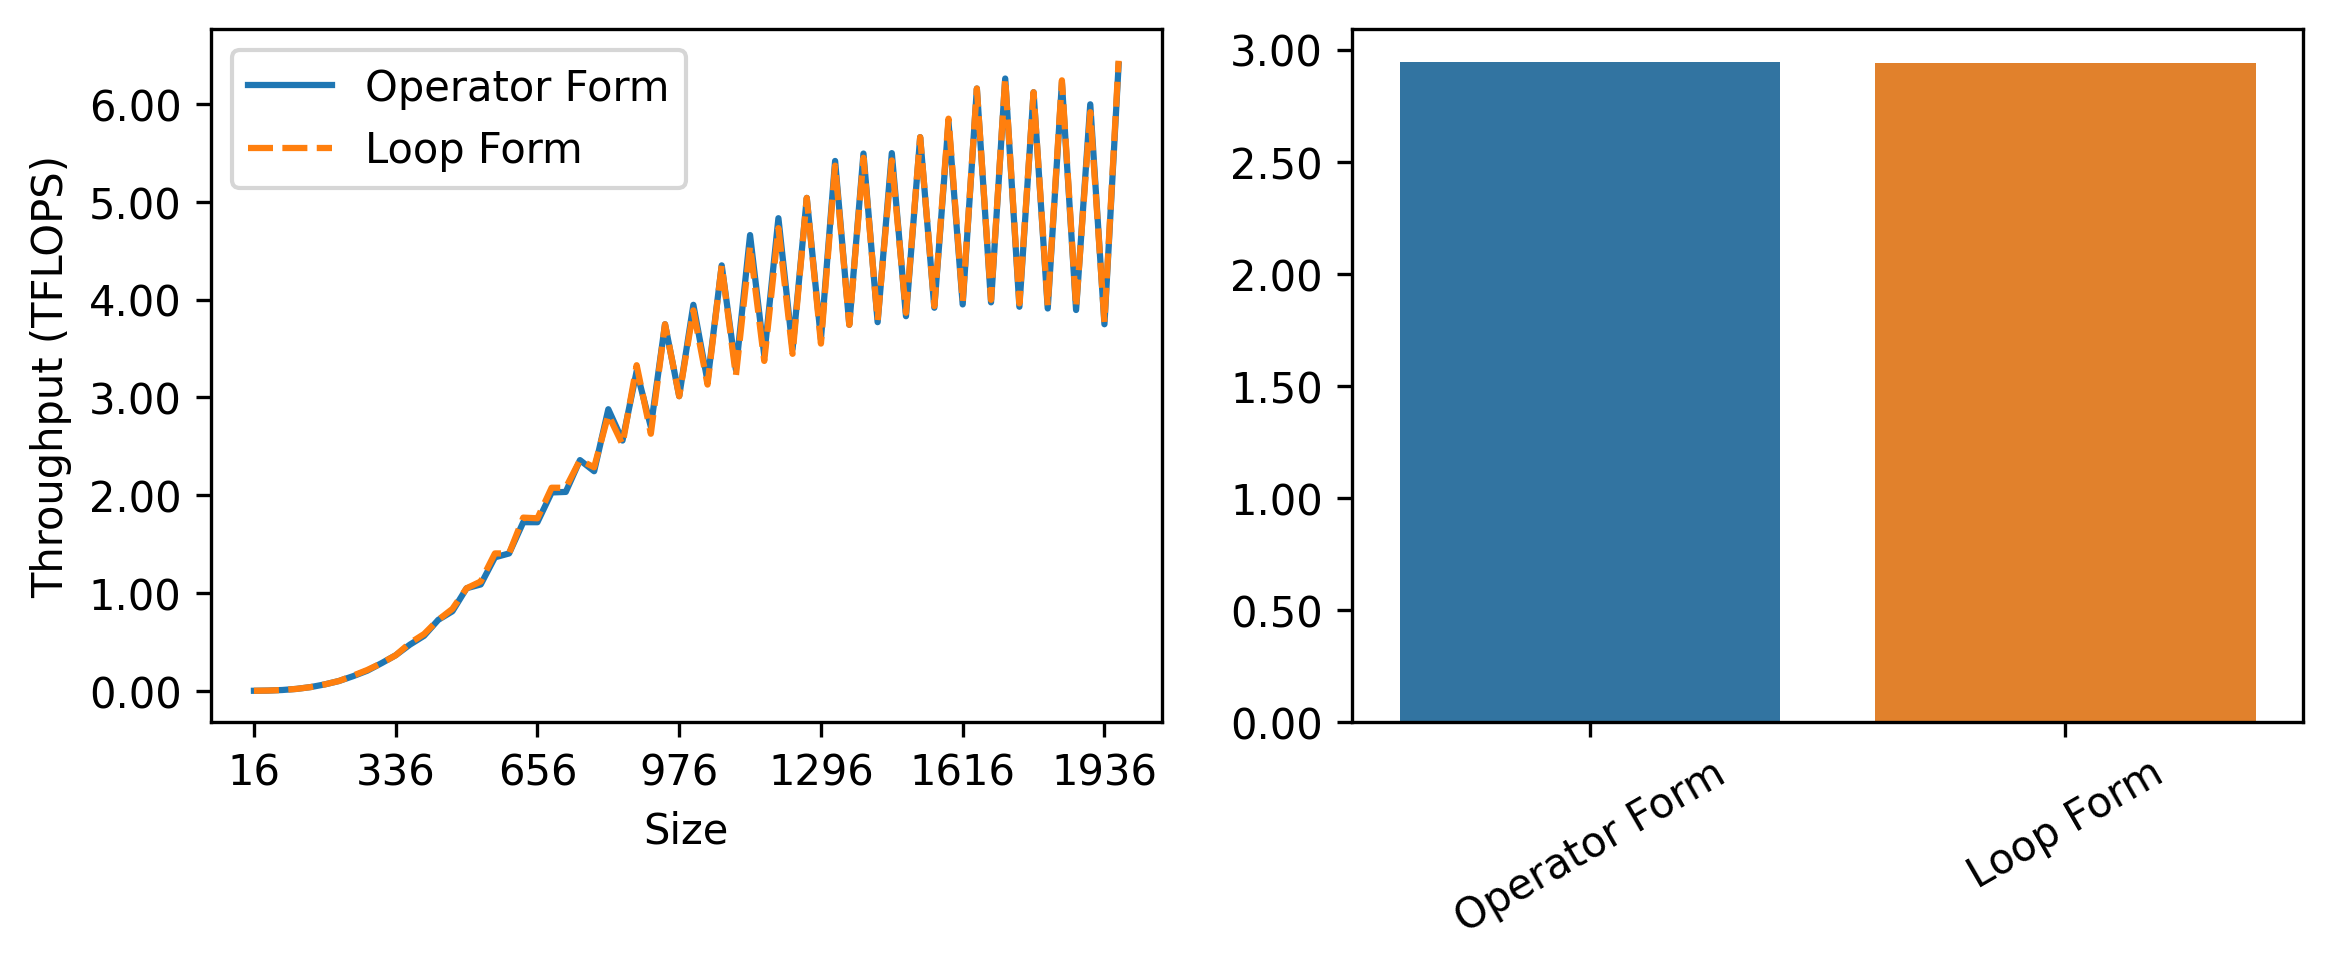

/tmp/ipykernel_1288232/3063586469.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0)
/tmp/ipykernel_1288232/3063586469.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  right.set_xticklabels(right.get_xticklabels(), rotation=30)


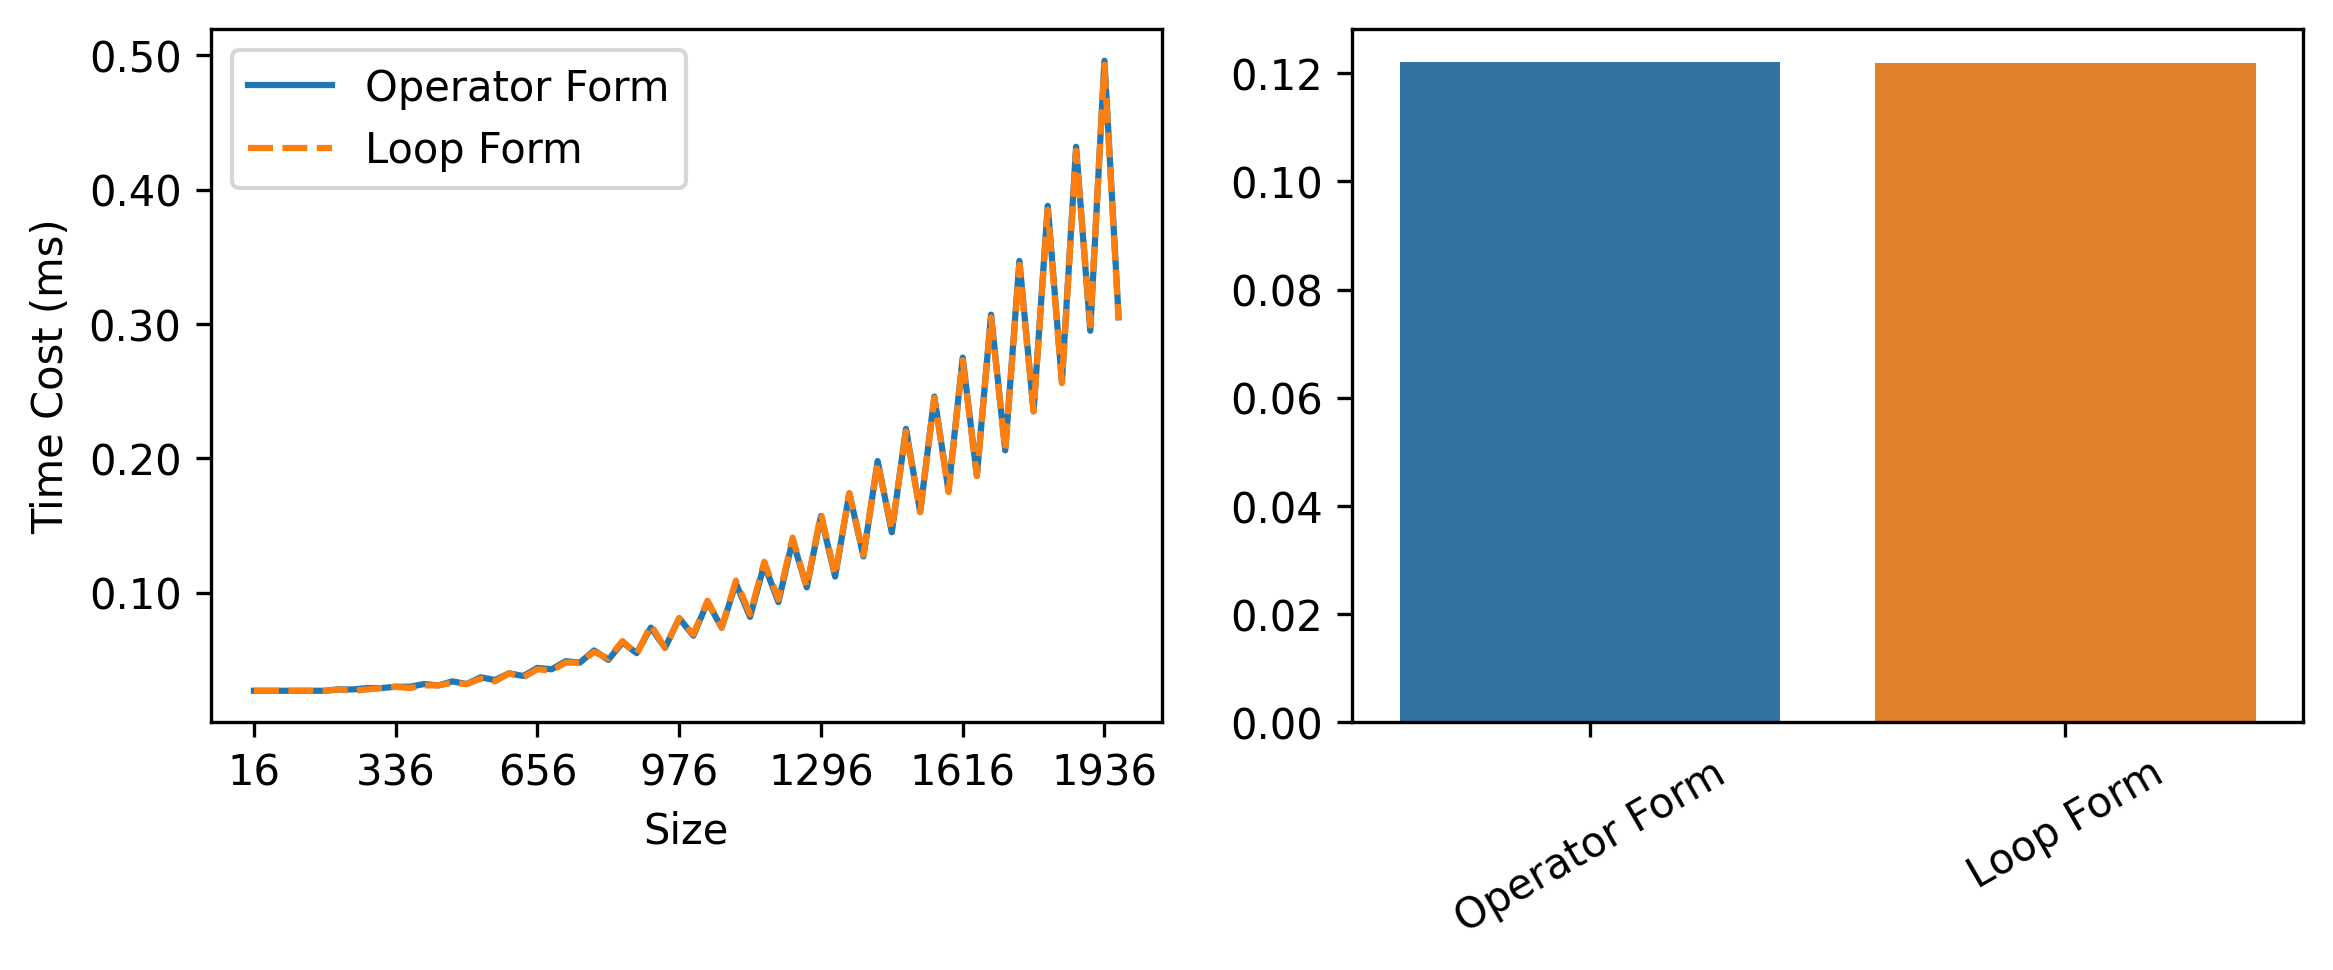

In [4]:
# do throughput
names = ['Operator Form', 'Loop Form']
results = [mm_results, gen_results]
throughputs = [mm_throughput, gen_throughput]

from matplotlib.ticker import FuncFormatter
line_data = pd.DataFrame(dict(zip(names, [res for res in throughputs])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in throughputs])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Throughput (TFLOPS)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1e18)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()

line_data = pd.DataFrame(dict(zip(names, [res for res in results])))
bar_data = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))
fig, (left, right) = plt.subplots(ncols=2, figsize=(9, 3))
left.set_ylabel('Time Cost (ms)')
left.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
#right.set_ylabel('Throughput (TFLOPS)')
right.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:,.02f}'.format(y / 1)))
sns.lineplot(line_data, ax=left)
sns.barplot(bar_data, ax=right)
left.set_xticklabels([f'{16 + (x-2)*320}' for x in range(1, len(line_data)+1)], rotation=0) 
left.set_xlabel('Size')
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
#plt.suptitle("Time Cost (ms)")
#plt.tight_layout(rect=[0, 0, 1, 1.2])
plt.show()